# Multiplicative Hencky plasticity: clamped beam under end traction

Demonstrates `PlasticityResidual`/`PlasticityJacobian`/`PlasticityResidualNeumann`/`AdvancePlasticityState`
from `FESolid2D` (multiplicative Hencky plasticity, von Mises/J2 yield, linear+Voce
hardening, plane strain) on the same clamp-left/traction-right beam used in
`Hyperelasticity2D.ipynb`, so the two are directly comparable.

We run the **same load-stepped traction** through two materials — one that never
yields (`sigma_0` huge, a pure-elastic reference) and one with a realistic yield
stress — and compare the load-displacement response. Plasticity, unlike the
hyperelasticity notebook, has genuine **history state**: `AdvancePlasticityState`
must be called once per load step, only after that step's Newton solve has
converged, to advance the frozen `Cᵖ⁻¹`/accumulated-plastic-strain state used by
the *next* step.

Requires `FESolid2D` to be `dev`'d into your environment: `] dev <path-to-fe-demo>`,
plus `NLsolve` and `Plots`.

In [1]:
using FESolid2D
using LinearAlgebra
using NLsolve
using Plots

default(linewidth=2)

## Mesh, materials, and boundary conditions

Two materials sharing the same elastic constants: `params_elastic` has a huge
`sigma_0` (never yields, a pure-elastic reference) and `params_plastic` has a
realistic yield stress + linear/Voce hardening.

In [2]:
P, Q, num_comp, Qmode = 2, 2, 2, "GAUSS"
Bx = FEBasis(2, Q, 2, Qmode)
Bu = FEBasis(P, Q, num_comp, Qmode)

nx, ny, aspect_ratio = 16, 4, 4   # domain: x in [0,1], y in [0, 1/aspect_ratio]
xc, yc = GetCoordMesh("uniform", nx, ny, aspect_ratio)
Ind = FEIndices(P, num_comp, nx, ny)

lambda, mu = 1.0, 1.0
bulk = lambda + 2mu / 3
params_plastic = PlasticityParams(bulk, mu, 0.03, 0.05, 0.05, 5.0)  # sigma_0, H, sigma_inf, omega
params_elastic = PlasticityParams(bulk, mu, 1e6, 0.0, 1e6, 1.0)     # sigma_0 huge: never yields

# Clamp: u = 0 on the left edge (both components)
bc_idx = GetDirichletBCsIndex(num_comp, Ind, (:left,))
u_bc = zeros(length(bc_idx))

# Traction: pull in +x on the right edge; top/bottom stay natural (free)
Fx = FEFaceIndices(P, num_comp, nx, ny, Ind, "right")
t0 = 0.045
t_right(x, y) = [t0 .* ones(length(x)); zeros(length(x))]
Ft_full = GetTractionGlobal(xc, yc, Fx, Ind, Bu, t_right)

f_zero(lambda, mu, x, y) = zeros(2 * length(x)) # no body force

u_dof = num_comp * maximum(Ind.idx_u)
num_nodes = maximum(Ind.idx_u)

## Load-stepping Newton solve, with state advance

`AdvancePlasticityState` is called once per step, only after `result.f_converged`
— it recomputes the local state at the converged `u` and returns the frozen
history to use as the starting point for the *next* step.

In [3]:
function run_loadsteps(params, nsteps)
    states = fill(VirginPlasticityState(), Bu.Q^2, size(Ind.idx_u, 2))
    u = zeros(u_dof)
    load_fracs = [0.0]
    tip_disp = [0.0]
    for s = 1:nsteps
        frac = s / nsteps
        Ft = frac .* Ft_full
        result = nlsolve(
            uu -> PlasticityResidualNeumann(params, uu, xc, yc, Ind, Bx, Bu, f_zero, bc_idx, u_bc, states, Ft),
            uu -> PlasticityJacobian(params, uu, xc, yc, Ind, Bx, Bu, bc_idx, states),
            u; method=:newton)
        @assert result.f_converged "step $s did not converge"
        u = result.zero
        states = AdvancePlasticityState(params, u, xc, yc, Ind, Bx, Bu, states)
        push!(load_fracs, frac)
        push!(tip_disp, maximum(u[1:num_nodes])) # max x-displacement (right edge)
    end
    return load_fracs, tip_disp, u
end

nsteps = 15
frac_e, disp_e, u_e = run_loadsteps(params_elastic, nsteps)
frac_p, disp_p, u_p = run_loadsteps(params_plastic, nsteps)
@show disp_e[end], disp_p[end];

(disp_e[end], disp_p[end]) = (0.017231443899439102, 0.10745638363902227)


## Load-displacement curve: elastic reference vs. yielding

The two curves should be **identical** while the plastic material stays below
its yield stress, then visibly diverge once yielding starts — same load
increment producing a much larger displacement increment (reduced tangent
stiffness) in the plastic case.

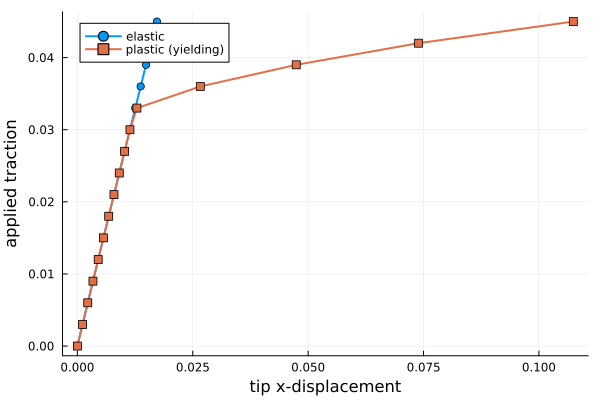

In [4]:
p1 = plot(disp_e, frac_e .* t0, label="elastic", xlabel="tip x-displacement", ylabel="applied traction",
    marker=:circle, legend=:topleft)
plot!(p1, disp_p, frac_p .* t0, label="plastic (yielding)", marker=:square)

## Visualize: undeformed vs. deformed mesh (plastic case)

For `P=2` the solution nodes coincide exactly with the geometry corner nodes, so
`xc,yc` index the same nodes as `u`.

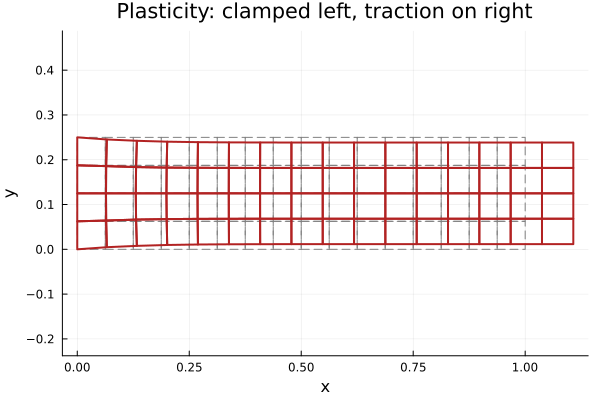

In [5]:
xdef = xc .+ u_p[1:num_nodes]
ydef = yc .+ u_p[num_nodes+1:end]

function plot_mesh!(p, x, y, idx_x; kwargs...)
    order = [1, 2, 4, 3, 1]
    for e in 1:size(idx_x, 2)
        plot!(p, x[idx_x[order, e]], y[idx_x[order, e]]; legend=false, kwargs...)
    end
    return p
end

p2 = plot(aspect_ratio=:equal, xlabel="x", ylabel="y", title="Plasticity: clamped left, traction on right")
plot_mesh!(p2, xc, yc, Ind.idx_x, color=:gray, linestyle=:dash, linewidth=1)
plot_mesh!(p2, xdef, ydef, Ind.idx_x, color=:firebrick, linewidth=2)
p2